In [1]:
# Vision Transformer with CNN
import torch
from torch import nn
from einops import rearrange, repeat
from einops.layers.torch import Rearrange

# helpers
def pair(t):
    return t if isinstance(t, tuple) else (t, t)

# ---------------------------
# CNN
# ---------------------------
class CNNLocalFeature(nn.Module):
    def __init__(self, in_channels=3, out_channels=64):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1),
            nn.ReLU()
        )

    def forward(self, x):
        return self.conv(x)  # [B, C, H, W]

class FeedForward(nn.Module):
    def __init__(self, dim, hidden_dim, dropout = 0.):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.net(x)
    
class Attention(nn.Module):
    def __init__(self, dim, heads = 8, dim_head = 64, dropout = 0.):
        super().__init__()
        inner_dim = dim_head *  heads
        project_out = not (heads == 1 and dim_head == dim)

        self.heads = heads
        self.scale = dim_head ** -0.5

        self.norm = nn.LayerNorm(dim)
        self.attend = nn.Softmax(dim = -1)
        self.dropout = nn.Dropout(dropout)
        self.to_qkv = nn.Linear(dim, inner_dim * 3, bias = False)
        self.to_out = nn.Sequential(
            nn.Linear(inner_dim, dim),
            nn.Dropout(dropout)
        ) if project_out else nn.Identity()

    def forward(self, x):
        x = self.norm(x)
        qkv = self.to_qkv(x).chunk(3, dim = -1)
        q, k, v = map(lambda t: rearrange(t, 'b n (h d) -> b h n d', h = self.heads), qkv)
        dots = torch.matmul(q, k.transpose(-1, -2)) * self.scale
        attn = self.attend(dots)
        attn = self.dropout(attn)
        out = torch.matmul(attn, v)
        out = rearrange(out, 'b h n d -> b n (h d)')
        return self.to_out(out)
    
class LocalAttention(nn.Module):
    def __init__(self, dim, heads=8, dim_head=64, window_size=3, dropout=0.):
        super().__init__()
        self.heads = heads
        self.scale = dim_head ** -0.5
        self.window_size = window_size
        self.norm = nn.LayerNorm(dim)
        self.to_qkv = nn.Linear(dim, dim_head * heads * 3, bias=False)
        self.attend = nn.Softmax(dim=-1)
        self.dropout = nn.Dropout(dropout)
        self.to_out = nn.Linear(dim_head * heads, dim)

    def forward(self, x):
        x = self.norm(x)
        b, n, d = x.shape
        h = self.heads
        dim_head = d // h
        qkv = self.to_qkv(x).chunk(3, dim=-1)
        q, k, v = map(lambda t: rearrange(t, 'b n (h d) -> b h n d', h=h), qkv)

        pad = self.window_size // 2
        k = torch.cat([torch.zeros(b, h, pad, dim_head, device=x.device), k,
                       torch.zeros(b, h, pad, dim_head, device=x.device)], dim=2)
        v = torch.cat([torch.zeros(b, h, pad, dim_head, device=x.device), v,
                       torch.zeros(b, h, pad, dim_head, device=x.device)], dim=2)

        out = []
        for i in range(n):
            k_local = k[:, :, i:i+self.window_size, :]
            v_local = v[:, :, i:i+self.window_size, :]
            attn = torch.matmul(q[:, :, i:i+1, :], k_local.transpose(-1, -2)) * self.scale
            attn = self.attend(attn)
            attn = self.dropout(attn)
            out.append(torch.matmul(attn, v_local))
        out = torch.cat(out, dim=2)
        out = rearrange(out, 'b h n d -> b n (h d)')
        return self.to_out(out)

class Transformer(nn.Module):
    def __init__(self, dim, depth, heads, dim_head, mlp_dim, dropout = 0.):
        super().__init__()
        self.norm = nn.LayerNorm(dim)
        self.layers = nn.ModuleList([])

        """
        Using Global attention
        """
        # for _ in range(depth):
        #     self.layers.append(nn.ModuleList([
        #         Attention(dim, heads = heads, dim_head = dim_head, dropout = dropout),
        #         FeedForward(dim, mlp_dim, dropout = dropout)
        #     ]))

        """
        Using Local attention
        """
        for _ in range(depth):
            self.layers.append(nn.ModuleList([
                LocalAttention(dim, heads=heads, dim_head=dim_head, window_size=3, dropout=dropout),
                FeedForward(dim, mlp_dim, dropout=dropout)
            ]))

    def forward(self, x):
        for attn, ff in self.layers:
            x = attn(x) + x
            x = ff(x) + x

        return self.norm(x)
    def forward(self, x):
        for attn, ff in self.layers:
            x = attn(x) + x
            x = ff(x) + x
        return self.norm(x)

# ---------------------------
# ViT with CNN fusion
# ---------------------------
class ViTWithCNN(nn.Module):
    def __init__(self, *, image_size, patch_size, num_classes, dim, depth, heads, mlp_dim, pool='cls', channels=3, dim_head=64, dropout=0., emb_dropout=0., cnn_channels=64):
        super().__init__()
        image_height, image_width = pair(image_size)
        patch_height, patch_width = pair(patch_size)

        self.patch_height = patch_height
        self.patch_width = patch_width
        self.cnn = CNNLocalFeature(in_channels=channels, out_channels=cnn_channels)
        self.linear_proj = nn.Linear(cnn_channels * patch_height * patch_width, dim)  # project CNN patch to ViT dim

        num_patches = (image_height // patch_height) * (image_width // patch_width)
        self.num_patches = num_patches

        self.to_patch_embedding = nn.Sequential(
            Rearrange('b c (h p1) (w p2) -> b (h w) (p1 p2 c)', p1 = patch_height, p2 = patch_width),
            nn.LayerNorm(channels * patch_height * patch_width),
            nn.Linear(channels * patch_height * patch_width, dim),
            nn.LayerNorm(dim),
        )

        self.pos_embedding = nn.Parameter(torch.randn(1, num_patches + 1, dim))
        self.cls_token = nn.Parameter(torch.randn(1, 1, dim))
        self.dropout = nn.Dropout(emb_dropout)

        self.transformer = Transformer(dim, depth, heads, dim_head, mlp_dim, dropout)
        self.pool = pool
        self.to_latent = nn.Identity()
        self.mlp_head = nn.Linear(dim, num_classes)

    def forward(self, img):
        # CNN features
        cnn_feat = self.cnn(img)  # [B, C, H, W]
        # patchify CNN
        B, C, H, W = cnn_feat.shape
        ph, pw = self.patch_height, self.patch_width
        cnn_patches = rearrange(cnn_feat, 'b c (h p1) (w p2) -> b (h w) (p1 p2 c)', p1=ph, p2=pw)
        cnn_tokens = self.linear_proj(cnn_patches)

        # ViT patch embeddings
        vit_tokens = self.to_patch_embedding(img)

        # merge CNN and ViT tokens
        x = vit_tokens + cnn_tokens  # simple addition fusion

        b, n, _ = x.shape
        cls_tokens = repeat(self.cls_token, '1 1 d -> b 1 d', b=b)
        x = torch.cat((cls_tokens, x), dim=1)
        x += self.pos_embedding[:, :(n+1)]
        x = self.dropout(x)

        x = self.transformer(x)
        x = x.mean(dim=1) if self.pool == 'mean' else x[:, 0]
        x = self.to_latent(x)
        return self.mlp_head(x)


In [17]:
# Vision Transformer with CNN
import torch
from torch import nn
from einops import rearrange, repeat
from einops.layers.torch import Rearrange

# helpers
def pair(t):
    return t if isinstance(t, tuple) else (t, t)

# ---------------------------
# CNN
# ---------------------------
class CNNLocalFeature(nn.Module):
    def __init__(self, in_channels=3, out_channels=64):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1),
            nn.ReLU()
        )

    def forward(self, x):
        return self.conv(x)  # [B, C, H, W]

class FeedForward(nn.Module):
    def __init__(self, dim, hidden_dim, dropout = 0.):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.net(x)
    
class Attention(nn.Module):
    def __init__(self, dim, heads = 8, dim_head = 64, dropout = 0.):
        super().__init__()
        inner_dim = dim_head *  heads
        project_out = not (heads == 1 and dim_head == dim)

        self.heads = heads
        self.scale = dim_head ** -0.5

        self.norm = nn.LayerNorm(dim)
        self.attend = nn.Softmax(dim = -1)
        self.dropout = nn.Dropout(dropout)
        self.to_qkv = nn.Linear(dim, inner_dim * 3, bias = False)
        self.to_out = nn.Sequential(
            nn.Linear(inner_dim, dim),
            nn.Dropout(dropout)
        ) if project_out else nn.Identity()

    def forward(self, x):
        x = self.norm(x)
        qkv = self.to_qkv(x).chunk(3, dim = -1)
        q, k, v = map(lambda t: rearrange(t, 'b n (h d) -> b h n d', h = self.heads), qkv)
        dots = torch.matmul(q, k.transpose(-1, -2)) * self.scale
        attn = self.attend(dots)
        attn = self.dropout(attn)
        out = torch.matmul(attn, v)
        out = rearrange(out, 'b h n d -> b n (h d)')
        return self.to_out(out)
    
class LocalAttention(nn.Module):
    def __init__(self, dim, heads=8, window_size=3, dropout=0.):
        super().__init__()
        self.heads = heads
        self.window_size = window_size

        self.norm = nn.LayerNorm(dim)
        self.to_qkv = nn.Linear(dim, dim * 3, bias=False)

        self.scale = (dim // heads) ** -0.5
        self.attend = nn.Softmax(dim=-1)
        self.dropout = nn.Dropout(dropout)

        self.to_out = nn.Linear(dim, dim)

    def forward(self, x):
        x = self.norm(x)
        b, n, d = x.shape
        h = self.heads
        dim_head = d // h

        qkv = self.to_qkv(x).chunk(3, dim=-1)
        q, k, v = map(
            lambda t: rearrange(t, 'b n (h d) -> b h n d', h=h),
            qkv
        )

        pad = self.window_size // 2
        k = torch.cat([torch.zeros(b, h, pad, dim_head, device=x.device), k,
                       torch.zeros(b, h, pad, dim_head, device=x.device)], dim=2)
        v = torch.cat([torch.zeros(b, h, pad, dim_head, device=x.device), v,
                       torch.zeros(b, h, pad, dim_head, device=x.device)], dim=2)

        out = []
        for i in range(n):
            k_local = k[:, :, i:i+self.window_size]
            v_local = v[:, :, i:i+self.window_size]
            attn = torch.matmul(q[:, :, i:i+1], k_local.transpose(-1, -2)) * self.scale
            attn = self.attend(attn)
            attn = self.dropout(attn)
            out.append(torch.matmul(attn, v_local))

        out = torch.cat(out, dim=2)
        out = rearrange(out, 'b h n d -> b n (h d)')
        return self.to_out(out)

class Transformer(nn.Module):
    def __init__(self, dim, depth, heads, mlp_dim, dropout=0.):
        super().__init__()
        self.norm = nn.LayerNorm(dim)
        self.layers = nn.ModuleList([])

        for _ in range(depth):
            self.layers.append(nn.ModuleList([
                LocalAttention(
                    dim=dim,
                    heads=heads,
                    window_size=3,
                    dropout=dropout
                ),
                FeedForward(dim, mlp_dim, dropout=dropout)
            ]))

    def forward(self, x):
        for attn, ff in self.layers:
            x = attn(x) + x
            x = ff(x) + x
        return self.norm(x)

# ---------------------------
# ViT with CNN fusion
# ---------------------------
class ViTWithCNN(nn.Module):
    def __init__(self, *, image_size, patch_size, num_classes, dim, depth, heads, mlp_dim, pool='cls', channels, dropout, emb_dropout, cnn_channels):
        super().__init__()
        image_height, image_width = pair(image_size)
        patch_height, patch_width = pair(patch_size)

        self.patch_height = patch_height
        self.patch_width = patch_width
        self.cnn = CNNLocalFeature(in_channels=channels, out_channels=cnn_channels)
        self.linear_proj = nn.Linear(cnn_channels * patch_height * patch_width, dim)  # project CNN patch to ViT dim

        num_patches = (image_height // patch_height) * (image_width // patch_width)
        self.num_patches = num_patches

        self.to_patch_embedding = nn.Sequential(
            Rearrange('b c (h p1) (w p2) -> b (h w) (p1 p2 c)', p1 = patch_height, p2 = patch_width),
            nn.LayerNorm(channels * patch_height * patch_width),
            nn.Linear(channels * patch_height * patch_width, dim),
            nn.LayerNorm(dim),
        )

        self.dropout = nn.Dropout(emb_dropout)
        self.pos_embedding = nn.Parameter(torch.randn(1, num_patches, dim))
        self.transformer = Transformer(dim, depth, heads, mlp_dim, dropout)
        self.pool = "mean"
        self.to_latent = nn.Identity()
        self.mlp_head = nn.Linear(dim, num_classes)

    def forward(self, img):
        cnn_feat = self.cnn(img) 

        B, C, H, W = cnn_feat.shape
        ph, pw = self.patch_height, self.patch_width

        cnn_patches = rearrange(
            cnn_feat, 
            'b c (h p1) (w p2) -> b (h w) (p1 p2 c)', 
            p1=ph, p2=pw
        )
        cnn_tokens = self.linear_proj(cnn_patches)

        vit_tokens = self.to_patch_embedding(img)

        x = vit_tokens + cnn_tokens 
        b, n, _ = x.shape
        x = x + self.pos_embedding[:, :n]
        x = self.dropout(x)

        x = self.transformer(x)
        x = x.mean(dim=1)  
        return self.mlp_head(x)



In [2]:
import librosa
import torch
import os
import numpy as np
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader
import pandas as pd

# def extract_features(file_path, n_mfcc=40):
#     y, sr = librosa.load(file_path, sr=None)  # load audio
#     mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
#     mfcc = np.mean(mfcc.T, axis=0)  # average across time
#     return mfcc


def extract_features(file_path, n_mfcc=64, max_len=128):
    y, sr = librosa.load(file_path, sr=None)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)

    # pad or crop time axis
    if mfcc.shape[1] < max_len:
        mfcc = np.pad(mfcc, ((0,0),(0, max_len - mfcc.shape[1])))
    else:
        mfcc = mfcc[:, :max_len]

    return mfcc

data_dir = r"C:\Coding\IEMOCAP\IEMOCAP\Cleaned\audios"
label_file = r"C:\Coding\IEMOCAP\IEMOCAP\Cleaned\labels.csv"
labels_df = pd.read_csv(label_file)

X_list = []
y_list = []

# emotion_map = {'anger':0, 'happiness':1, 'sadness':2, 'neutral':3, 'frustration':4}
# emotion_map = {
#     "neutral":0,
#     "frustration":1,
#     "sadness":2,
#     "anger":4,
#     "happiness":5,
#     "excitement":6,
#     "excited":6
# }
emotion_map = {
    "neutral":0,
    "sadness":1,
    "anger":2,
    "happiness":3,
    "excitement":4,
    "excited":4
}
for idx, row in labels_df.iterrows():
    filename = row['Filename'] + '.wav'  # add extension
    file_path = os.path.join(data_dir, filename)
    
    if not os.path.exists(file_path):
        print(f"File not found: {file_path}")
        continue
    
        
    emotion = row['Label'].lower()  # convert to lowercase
    if emotion not in emotion_map:
        print(f"Skipping unknown emotion: {emotion}")
        continue
    
    features = extract_features(file_path)
    X_list.append(features)
    y_list.append(emotion_map[emotion])

print("Total samples loaded:", len(X_list), len(y_list))

X = torch.tensor(np.array(X_list), dtype=torch.float32)
X = X.unsqueeze(1)
y = torch.tensor(np.array(y_list), dtype=torch.long)

dataset = TensorDataset(X, y)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)


Skipping unknown emotion: frustration
Skipping unknown emotion: frustration
Skipping unknown emotion: frustration
Skipping unknown emotion: frustration
Skipping unknown emotion: frustration
Skipping unknown emotion: frustration
Skipping unknown emotion: frustration
Skipping unknown emotion: frustration
Skipping unknown emotion: frustration
Skipping unknown emotion: frustration
Skipping unknown emotion: frustration
Skipping unknown emotion: frustration
Skipping unknown emotion: frustration
Skipping unknown emotion: frustration
Skipping unknown emotion: frustration
Skipping unknown emotion: frustration
Skipping unknown emotion: frustration
Skipping unknown emotion: frustration
Skipping unknown emotion: frustration
Skipping unknown emotion: frustration
Skipping unknown emotion: frustration
Skipping unknown emotion: frustration
Skipping unknown emotion: frustration
Skipping unknown emotion: frustration
Skipping unknown emotion: frustration
Skipping unknown emotion: frustration
Skipping unk

In [19]:
idx_to_emotion = {v: k for k, v in emotion_map.items()}

unique, counts = torch.unique(y, return_counts=True)

print("Class distribution:")
for u, c in zip(unique.tolist(), counts.tolist()):
    emotion_name = idx_to_emotion.get(u, "UNKNOWN")
    print(f"Class {u} {emotion_name} : {c}")

Class distribution:
Class 0 neutral : 1768
Class 1 frustration : 2874
Class 2 sadness : 1253
Class 3 surprise : 125
Class 4 anger : 1284
Class 5 happiness : 708
Class 6 excited : 1883
Class 7 fear : 105
Class 8 disgust : 3
Class 9 other : 36


In [13]:
idx_to_emotion = {v: k for k, v in emotion_map.items()}

unique, counts = torch.unique(y, return_counts=True)

print("Class distribution:")
for u, c in zip(unique.tolist(), counts.tolist()):
    emotion_name = idx_to_emotion.get(u, "UNKNOWN")
    print(f"Class {u} {emotion_name} : {c}")

Class distribution:
Class 0 neutral : 1768
Class 1 frustration : 2874
Class 2 sadness : 1253
Class 4 anger : 1284
Class 5 happiness : 708
Class 6 excited : 1883


In [17]:
train_labels = torch.tensor([y for _, y in train_dataset])

unique, counts = torch.unique(train_labels, return_counts=True)

print("Train class distribution:")
for u, c in zip(unique.tolist(), counts.tolist()):
    emotion_name = idx_to_emotion.get(u, "UNKNOWN")
    print(f"Class {u} ({emotion_name}) : {c}")

Train class distribution:
Class 0 (neutral) : 1451
Class 1 (frustration) : 2291
Class 2 (sadness) : 1007
Class 4 (anger) : 1029
Class 5 (happiness) : 553
Class 6 (excited) : 1485


In [19]:
vit_model.eval()
dummy = torch.randn(2, 1, 64, 128).to(device)
out = vit_model(dummy)
print(out.shape)

torch.Size([2, 6])


In [ ]:
import torch,random
from torch import nn, optim
from collections import defaultdict
from torch.utils.data import DataLoader, Subset

batch_size = 32
num_epochs = 20
device = "cuda" if torch.cuda.is_available() else "cpu"
MIN_TEST_PER_CLASS = 100

class_indices = defaultdict(list)
for i in range(len(dataset)):
    _, y = dataset[i]
    if torch.is_tensor(y):
        y = y.item()
    class_indices[y].append(i)

train_idx, test_idx = [], []
for y, idxs in class_indices.items():
    if len(idxs) < MIN_TEST_PER_CLASS:
        raise ValueError(f"class {y} has only {len(idxs)} samples")
    random.shuffle(idxs)
    test_idx += idxs[:MIN_TEST_PER_CLASS]
    train_idx += idxs[MIN_TEST_PER_CLASS:]

train_dataset = Subset(dataset, train_idx)
test_dataset  = Subset(dataset, test_idx)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


# vit_model = ViT(
#     image_size=(64, 128),
#     patch_size=patch_size,
#     num_classes=len(emotion_map),
#     dim=512,
#     depth=6,
#     heads=8,
#     mlp_dim=1024,
#     channels=1,
#     dropout=0.1,
#     emb_dropout=0.1
# ).to(device)


vit_model = ViTWithCNN(
    image_size=(64, 128),
    patch_size=(8, 8),
    num_classes=len(emotion_map),
    dim=256,
    depth=6,
    heads=8,
    mlp_dim=1024,
    channels=1,
    dropout=0.1,
    emb_dropout=0.1,
    cnn_channels=64
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(vit_model.parameters(), lr=1e-4)

for epoch in range(num_epochs):
    vit_model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        # print(X_batch.shape)
        outputs = vit_model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == y_batch).sum().item()
        total += y_batch.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.4f}")


Epoch [1/20] - Loss: 1.4602, Accuracy: 0.3590
Epoch [2/20] - Loss: 1.3794, Accuracy: 0.4087
Epoch [3/20] - Loss: 1.3376, Accuracy: 0.4306
Epoch [4/20] - Loss: 1.3004, Accuracy: 0.4576
Epoch [5/20] - Loss: 1.2763, Accuracy: 0.4692
Epoch [6/20] - Loss: 1.2431, Accuracy: 0.4928


In [13]:
vit_model.eval()  # set model to evaluation mode

all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:  # use test_loader instead of train_loader
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        outputs = vit_model(X_batch)
        _, preds = torch.max(outputs, 1)

        all_preds.append(preds.cpu())
        all_labels.append(y_batch.cpu())

# Concatenate all batches
all_preds = torch.cat(all_preds)
all_labels = torch.cat(all_labels)

print(f"Test predictions: {all_preds.shape}, Test labels: {all_labels.shape}")


Test predictions: torch.Size([500]), Test labels: torch.Size([500])


Classification Report - Test Set
              precision    recall  f1-score   support

     neutral       0.34      0.55      0.42       100
     sadness       0.49      0.44      0.46       100
       anger       0.59      0.35      0.44       100
   happiness       0.31      0.17      0.22       100
     excited       0.31      0.41      0.35       100

    accuracy                           0.38       500
   macro avg       0.41      0.38      0.38       500
weighted avg       0.41      0.38      0.38       500



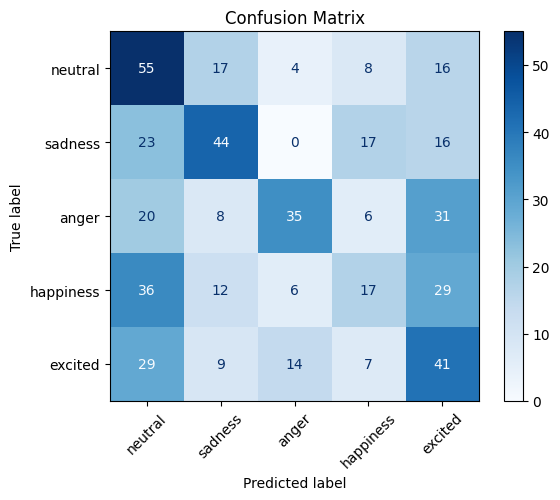

In [14]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Convert to numpy
y_true = all_labels.cpu().numpy()
y_pred = all_preds.cpu().numpy()

# Unique labels in test set
unique_labels = sorted(torch.unique(all_labels).tolist())

# Safe mapping
all_emotions = {v: k for k, v in emotion_map.items()}
# all_emotions = {0:'Angry', 1:'Happy', 2:'Sad', 3:'Neutral', 4:'Frustration'}
display_labels = [all_emotions[i] if i in all_emotions else f"Unknown({i})" for i in unique_labels]

# Classification report
report = classification_report(
    y_true,
    y_pred,
    labels=unique_labels,
    target_names=display_labels
)
print("Classification Report - Test Set")
print(report)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=unique_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()


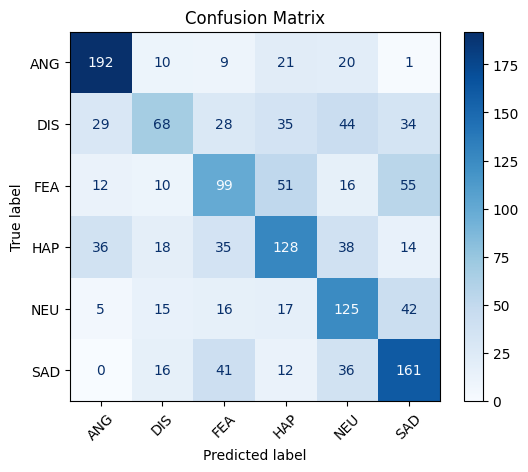

In [48]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred, labels=unique_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()
